# Stock Price Full EDA

In [63]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots appear inside notebook
%matplotlib inline

# Importing Dataset

In [64]:
stock_prices_data_set = pd.read_csv("2) Stock Prices Data Set (2).csv")
stock_prices_data_set.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


# Understanding The Dataset Structure

In [65]:
#Checking column types and dataset info
stock_prices_data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [66]:
#Checking dataset dimensions
stock_prices_data_set.shape

(497472, 7)

# Identify Missing Values

In [67]:
#Checking for missing values in each column
stock_prices_data_set.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

# Handle Missing Values

In [68]:
#Filling missing values
stock_prices_data_set['open'] = stock_prices_data_set['open'].fillna(stock_prices_data_set['open'].mean())
stock_prices_data_set['high'] = stock_prices_data_set['high'].fillna(stock_prices_data_set['high'].mean())
stock_prices_data_set['low'] = stock_prices_data_set['low'].fillna(stock_prices_data_set['low'].mean())
stock_prices_data_set['close'] = stock_prices_data_set['close'].fillna(stock_prices_data_set['close'].mean())

In [69]:
#Rechecking for missing values in each column after cleaning
stock_prices_data_set.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

# Remove Duplicate Rows

In [70]:
#First checking for duplicate rows
stock_prices_data_set.duplicated().sum()

np.int64(0)

# Standardize Inconsistent Data Formats

In [71]:
#Converting Date Column to Proper Format
stock_prices_data_set['date'] = pd.to_datetime(stock_prices_data_set['date'])

In [72]:
#Confirmimg date format
stock_prices_data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497472 non-null  float64       
 3   high    497472 non-null  float64       
 4   low     497472 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


# Standardize Categorical Variables

In [73]:
#Turning all available stock symbol lowercase to uppercase
stock_prices_data_set['symbol'] = stock_prices_data_set['symbol'].str.upper()

# Exploratory Data Analysis (EDA)

In [39]:
#Summary Statistics
stock_prices_data_set.describe()

,date,open,high,low,close,volume
count,497472,497472.000000,497472.000000,497472.000000,497472.000000,4.974720e+05
mean,2016-01-06 17:16:00.439984896,86.352275,87.132562,85.552467,86.369082,4.253611e+06
min,2014-01-02 00:00:00,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,2015-01-08 00:00:00,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,2016-01-11 00:00:00,64.970000,65.560000,64.360000,64.980000,2.084896e+06
75%,2017-01-06 00:00:00,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2017-12-29 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08
std,NaN,101.470106,102.311239,100.570148,101.472407,8.232139e+06


# Calculating summary statistics

In [40]:
stock_prices_data_set.mean(numeric_only=True)

open      8.635227e+01
high      8.713256e+01
low       8.555247e+01
close     8.636908e+01
volume    4.253611e+06
dtype: float64

In [41]:
stock_prices_data_set.median(numeric_only=True)

open           64.97
high           65.56
low            64.36
close          64.98
volume    2084896.50
dtype: float64

In [42]:
stock_prices_data_set.mode().iloc[0]

symbol                      A
date      2017-12-05 00:00:00
open                     70.0
high                     72.0
low                      77.0
close                    34.5
volume              1241019.0
Name: 0, dtype: object

In [43]:
stock_prices_data_set.std(numeric_only=True)

open      1.014701e+02
high      1.023112e+02
low       1.005701e+02
close     1.014724e+02
volume    8.232139e+06
dtype: float64

# Data Distribution Visualizations

# Histogram

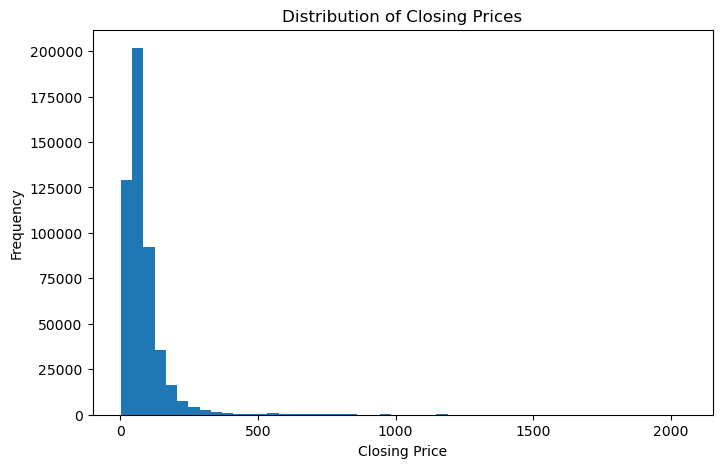

In [44]:
#Showing distribution of values.
plt.figure(figsize=(8,5))
plt.hist(stock_prices_data_set['close'], bins=50)
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot

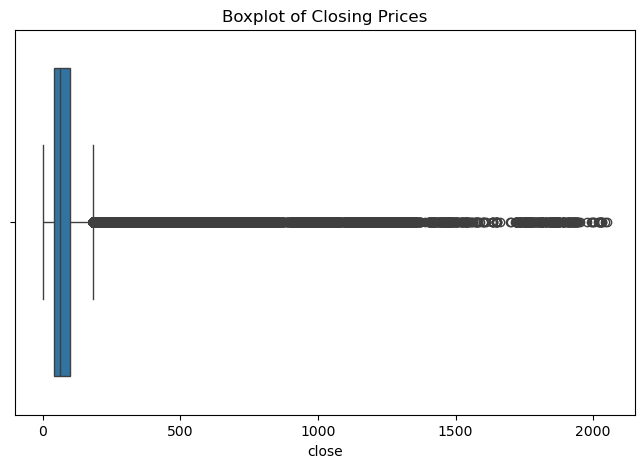

In [45]:
#Detecting outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=stock_prices_data_set['close'])
plt.title("Boxplot of Closing Prices")
plt.show()

# Scatter Plot

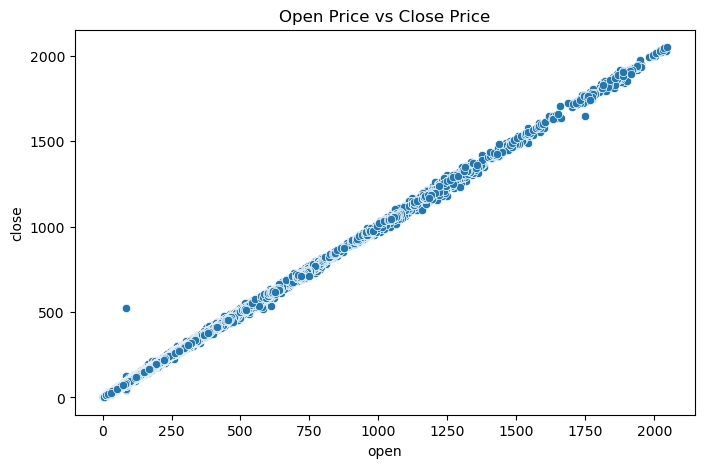

In [46]:
#Showing relationship between open price and close price variable
plt.figure(figsize=(8,5))
sns.scatterplot(x=stock_prices_data_set['open'], y=stock_prices_data_set['close'])
plt.title("Open Price vs Close Price")
plt.show()

# Correlation Between Numerical Features

In [47]:
#Calculating correlation matrix
correlation = stock_prices_data_set.corr(numeric_only=True)

correlation


,open,high,low,close,volume
open,1.000000,0.999941,0.999927,0.999856,-0.148724
high,0.999941,1.000000,0.999905,0.999918,-0.148344
low,0.999927,0.999905,1.000000,0.999922,-0.149284
close,0.999856,0.999918,0.999922,1.000000,-0.148839
volume,-0.148724,-0.148344,-0.149284,-0.148839,1.000000


# Heatmap Visualization

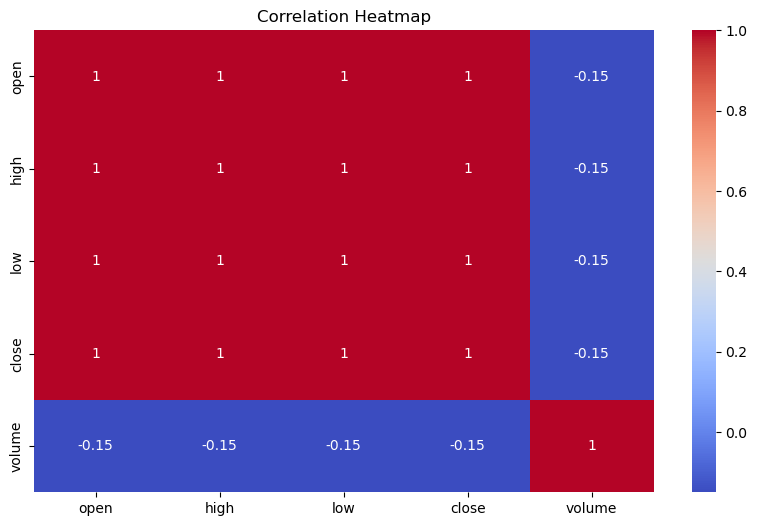

In [48]:
#To see how strongly the variables are related
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Identifying Patterns or Trends

In [49]:
#Top traded companies
stock_prices_data_set.groupby('symbol')['volume'].sum().sort_values(ascending=False).head()

symbol
BAC     89988444028
AAPL    45485758169
GE      41734050117
AMD     33522535638
F       33144701045
Name: volume, dtype: int64

In [50]:
#Average closing price per company
stock_prices_data_set.groupby('symbol')['close'].mean().sort_values(ascending=False).head()

symbol
PCLN     1390.272642
GOOGL     722.559017
GOOG      714.496848
AZO       660.246425
AMZN      619.244787
Name: close, dtype: float64

In [51]:
#Price volatility
stock_prices_data_set['volatility'] = stock_prices_data_set['high'] - stock_prices_data_set['low']
stock_prices_data_set[['symbol','volatility']].head()

,symbol,volatility
0,AAL,0.7600
1,AAPL,0.7155
2,AAP,2.5900
3,ABBV,0.8100
4,ABC,0.7500


# Key Insights

# 1) Most stocks in the dataset trade at relatively low prices, while only a small number of companies have extremely high stock prices. This indicates a highly skewed market distribution where a few premium stocks dominate the upper price range.
# 2) Stock price variables (open, high, low, close) are extremely strongly correlated, indicating that daily stock prices move very closely together within the same trading session.
# 3) Trading volume shows only a weak relationship with stock prices, suggesting that trading activity is influenced more by investor behavior, market news, or liquidity rather than price levels alone.
# 4) Opening and closing prices show a near-perfect linear relationship, meaning that most stocks close near their opening value with relatively small intraday price movements.
# 5) Certain companies dominate trading activity, such as BAC, AAPL, GE, AMD, and F, indicating that these stocks attract significantly higher investor attention and market participation.
# 6) Stock volatility varies across companies, with some stocks experiencing larger daily price fluctuations than others, indicating differences in investment risk and trading opportunities.

# TIME SERIES ANALYSIS

In [52]:
plt.figure(figsize=(10,5))
plt.plot(stock_prices_data_set['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

KeyError: 'Close'

<Figure size 1000x500 with 0 Axes>

In [53]:
plt.figure(figsize=(10,5))
plt.plot(stock_prices_data_set['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

KeyError: 'Close'

<Figure size 1000x500 with 0 Axes>

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(stock_prices_data_set['Date'], stock_prices_data_set['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

KeyError: 'Date'

<Figure size 1000x500 with 0 Axes>